# HeatSense Phase 1 — LSTM with Enriched Features

**Goal:** Beat the XGBoost baseline (MAE=0.230, Sens@38.5=0.419) by capturing temporal dynamics.

**Architecture:** LSTM(32) + Static Dense branch, same enriched features that proved valuable in Phase 0:
- `time_in_session` (r=0.72), `cumulative_HR` (r=0.77) — the features that broke through the CNN ceiling
- `Perceptual_TS` (forward-filled), `Activity_Workrest`
- Weighted MSE for elevated Tcore samples

**XGBoost baseline to beat:**
| Metric | XGBoost Phase 0 |
|---|---|
| MAE | 0.230 C |
| RMSE | 0.291 C |
| R² | 0.465 |
| Sens@38.0 | 0.635 |
| Sens@38.5 | 0.419 |
| CV MAE | 0.219 ± 0.021 |
| CV Sens@38.5 | 0.535 ± 0.068 |

## 1. Setup & Configuration

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Concatenate, ReLU,
    BatchNormalization, GaussianNoise,
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# --- Paths ---
DATA_DIR = '/content/drive/MyDrive/HeatSense'
RAW_DATA_PATH = os.path.join(DATA_DIR, 'sen_ds_raw.xlsx')
DATA_SHEET = 'Data'
OUTPUT_DIR = os.path.join(DATA_DIR, 'output')
MODEL_DIR = os.path.join(OUTPUT_DIR, 'models')

# --- Reproducibility ---
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# --- Column renames ---
COLUMN_RENAME = {
    'SkinTemp_upper_arm': 'SkinTemp_UpperArm',
    'Environmental_temperature_(chamber_or_cooling_area_outside_chamber)_Temp': 'Env_Temp',
    'Environmental_temperature_(chamber_or_cooling_area_outside_chamber)_Humidity': 'Env_Humidity',
    'InsulatedskinTemp_HR': 'HR',
    'Activity_code': 'Activity_Code',
    'Bodymasskg': 'Body_Mass_Kg',
    'Heightcm': 'Height_Cm',
    'Bodyfat%': 'Body_Fat_Pct',
    'VO2peakmlkgmin': 'VO2Peak',
    'Acclimationstatus': 'Acclimation_Status',
    'Trainingstatus': 'Training_Status',
}

MISSING_SENTINEL = 9999
TARGET = 'Corerectal'

# --- Dynamic features per timestep (fed to LSTM) ---
# These are the enriched features including the ones that broke the CNN ceiling
DYNAMIC_FEATURES = [
    'HR', 'SkinTemp_UpperArm', 'Env_Temp',
    'time_in_session', 'cumulative_HR',
    'HR_slope_5m', 'SkinTemp_slope_5m',
    'Perceptual_TS', 'Perceptual_TC',
    'Activity_Workrest',
]

# --- Static features (constant per participant, fed to Dense branch) ---
STATIC_FEATURES = ['Age', 'Sex_Encoded', 'BMI', 'VO2Peak',
                    'Acclimation_Encoded', 'Training_Encoded']

# --- Windowing ---
WINDOW_SIZE = 30
TRAIN_STRIDE = 5
EVAL_STRIDE = 5

# --- Model ---
LSTM_UNITS = 32
STATIC_DENSE_UNITS = 16
MERGE_DENSE_UNITS = 24
DROPOUT_RATE = 0.3
L2_REG = 1e-4
NOISE_STDDEV = 0.03
LEARNING_RATE = 1e-3
BATCH_SIZE = 32
MAX_EPOCHS = 200
EARLY_STOP_PATIENCE = 25
LR_REDUCE_PATIENCE = 10
LR_REDUCE_FACTOR = 0.5

# --- Weighted loss ---
ELEVATED_WEIGHT_ALPHA = 5.0
ELEVATED_WEIGHT_THRESHOLD = 37.5

# --- Split ---
TEST_SIZE = 0.30
VAL_FRACTION = 0.50

# --- Imputation ---
INTERPOLATION_LIMIT = 10
KNN_NEIGHBORS = 5

# --- Alert thresholds ---
ALERT_THRESHOLDS = {
    'normal': (-float('inf'), 38.0),
    'caution': (38.0, 38.5),
    'warning': (38.5, 39.0),
    'alarm': (39.0, float('inf')),
}

os.makedirs(MODEL_DIR, exist_ok=True)
print("Setup complete.")
print(f"  TensorFlow: {tf.__version__}")
print(f"  Dynamic features: {len(DYNAMIC_FEATURES)}")
print(f"  Static features: {len(STATIC_FEATURES)}")
print(f"  LSTM units: {LSTM_UNITS}")

Setup complete.
  TensorFlow: 2.19.0
  Dynamic features: 10
  Static features: 6
  LSTM units: 32


## 2. Load & Clean Data

In [ ]:
# ============================================================
# LOAD RAW DATA (same as Phase 0)
# ============================================================

def flatten_multiindex(df):
    new_cols = []
    for col in df.columns:
        lvl0 = str(col[0]).strip()
        lvl1 = str(col[1]).strip()
        if 'Unnamed' in lvl0:
            new_cols.append(lvl1)
        elif lvl0 == lvl1:
            new_cols.append(lvl0)
        else:
            new_cols.append(f"{lvl0}_{lvl1}")
    df.columns = new_cols
    df.columns = [c.split('_Unnamed')[0].strip().replace(' ', '_') for c in df.columns]
    return df

print("Loading raw data...")
df = pd.read_excel(RAW_DATA_PATH, sheet_name=DATA_SHEET, header=[0, 1])
df = flatten_multiindex(df)
df.rename(columns=COLUMN_RENAME, inplace=True)
df.replace([MISSING_SENTINEL, float(MISSING_SENTINEL)], np.nan, inplace=True)

# Session identification
df['Time_Sec'] = pd.to_timedelta(df['Time'].astype(str), errors='coerce').dt.total_seconds()
df['Session_ID'] = (
    (df['Participant'] != df['Participant'].shift(1)) |
    (df['Time_Sec'] < df['Time_Sec'].shift(1))
).cumsum()

# Forward-fill HR (P1-P18 5-min sampling)
before_nan = df['HR'].isna().sum()
for sid in df['Session_ID'].unique():
    mask = df['Session_ID'] == sid
    df.loc[mask, 'HR'] = df.loc[mask, 'HR'].ffill(limit=5)
print(f"  HR forward-fill: {before_nan - df['HR'].isna().sum()} resolved")

# Forward-fill perceptual inputs (recorded every ~10 min)
for col_pattern in ['Perceptual_TS', 'Perceptual_TC']:
    matches = [c for c in df.columns if col_pattern.split('_')[1] in c and 'Perceptual' in c]
    if matches:
        real_name = matches[0]
        before_p = df[real_name].isna().sum()
        for sid in df['Session_ID'].unique():
            mask = df['Session_ID'] == sid
            df.loc[mask, real_name] = df.loc[mask, real_name].ffill()
        after_p = df[real_name].isna().sum()
        if real_name != col_pattern:
            df.rename(columns={real_name: col_pattern}, inplace=True)
        print(f"  {col_pattern}: {(1 - after_p/len(df))*100:.1f}% coverage after ffill")

# Activity work/rest
workrest_candidates = [c for c in df.columns if 'workrest' in c.lower() or 'work_rest' in c.lower()]
if workrest_candidates:
    df.rename(columns={workrest_candidates[0]: 'Activity_Workrest'}, inplace=True)
else:
    for c in df.columns:
        if 'Activity' in c and 'workrest' in c.lower():
            df.rename(columns={c: 'Activity_Workrest'}, inplace=True)
            break

# Encode features
df['Sex_Encoded'] = df['Sex'].map({1: 1, 2: 0, '1': 1, '2': 0}).fillna(1).astype('float32')
height_m = (df['Height_Cm'] / 100).replace(0, np.nan)
df['BMI'] = (df['Body_Mass_Kg'] / (height_m ** 2)).astype('float32')
df['Acclimation_Encoded'] = df['Acclimation_Status'].astype('float32')
df['Training_Encoded'] = df['Training_Status'].map({1: 1, 2: 0}).fillna(0).astype('float32')

# Drop rows with no target
before = len(df)
df = df.dropna(subset=[TARGET]).copy()
print(f"  Dropped {before - len(df)} rows missing {TARGET}")

# Drop ghost rows
before = len(df)
df = df.dropna(subset=['HR', 'SkinTemp_UpperArm'], how='all').copy()
if before - len(df) > 0:
    print(f"  Dropped {before - len(df)} ghost rows")

print(f"\n  Final: {len(df)} rows, {df['Session_ID'].nunique()} sessions, "
      f"{df['Participant'].nunique()} participants")

Loading raw data...
  HR forward-fill: 5268 resolved
  Perceptual_TS: 99.9% coverage after ffill
  Perceptual_TC: 99.9% coverage after ffill
  Dropped 68 rows missing Corerectal

  Final: 17196 rows, 155 sessions, 40 participants


## 3. Feature Engineering

In [ ]:
# ============================================================
# FEATURE ENGINEERING (per-session)
# ============================================================

print("Engineering features per session...")
result_parts = []
for sid, session in df.groupby('Session_ID'):
    session = session.sort_values('Time_Sec').copy()

    # Time in session (minutes)
    session['time_in_session'] = (session['Time_Sec'] - session['Time_Sec'].iloc[0]) / 60.0

    # Cumulative HR (metabolic heat storage proxy)
    resting_hr = 70.0
    hr_filled = session['HR'].fillna(resting_hr)
    session['cumulative_HR'] = (hr_filled - resting_hr).clip(lower=0).cumsum()

    # Slopes
    session['HR_slope_5m'] = session['HR'].diff(periods=5).fillna(0)
    session['SkinTemp_slope_5m'] = session['SkinTemp_UpperArm'].diff(periods=5).fillna(0)

    # Activity (ensure numeric)
    if 'Activity_Workrest' in session.columns:
        session['Activity_Workrest'] = session['Activity_Workrest'].fillna(1).astype('float32')

    # Perceptual (fill remaining NaN with neutral values)
    for pc in ['Perceptual_TS', 'Perceptual_TC']:
        if pc in session.columns:
            session[pc] = session[pc].fillna(session[pc].median() if session[pc].notna().any() else 10.0)

    result_parts.append(session)

df = pd.concat(result_parts).sort_index()

# Verify all dynamic features exist
print(f"\nDynamic features for LSTM ({len(DYNAMIC_FEATURES)}):")
for f in DYNAMIC_FEATURES:
    if f in df.columns:
        valid = df[f].notna().sum()
        print(f"  {f:25s}: {valid}/{len(df)} ({valid/len(df)*100:.1f}%), "
              f"mean={df[f].mean():.2f}, std={df[f].std():.2f}")
    else:
        print(f"  {f:25s}: *** MISSING ***")

Engineering features per session...

Dynamic features for LSTM (10):
  HR                       : 17153/17196 (99.7%), mean=124.94, std=30.00
  SkinTemp_UpperArm        : 17092/17196 (99.4%), mean=36.44, std=1.45
  Env_Temp                 : 16960/17196 (98.6%), mean=34.91, std=7.19
  time_in_session          : 17196/17196 (100.0%), mean=56.92, std=34.33
  cumulative_HR            : 17196/17196 (100.0%), mean=2737.30, std=2144.43
  HR_slope_5m              : 17196/17196 (100.0%), mean=3.62, std=15.83
  SkinTemp_slope_5m        : 17196/17196 (100.0%), mean=0.17, std=0.57
  Perceptual_TS            : 17196/17196 (100.0%), mean=15.45, std=2.79
  Perceptual_TC            : 17196/17196 (100.0%), mean=13.26, std=4.48
  Activity_Workrest        : 17196/17196 (100.0%), mean=1.27, std=0.44


## 4. Split, Impute, Scale, Window

In [ ]:
# ============================================================
# SPLIT BY PARTICIPANT -> IMPUTE -> SCALE -> WINDOW
# ============================================================

# --- 1. Split by participant (stratified by max Tcore >= 39.0) ---
part_max = df.groupby('Participant')[TARGET].max()
high_tcore = (part_max >= 39.0).astype(int)
participants = high_tcore.index.values
labels = high_tcore.values

train_parts, temp_parts, _, temp_labels = train_test_split(
    participants, labels, test_size=TEST_SIZE,
    random_state=RANDOM_SEED, stratify=labels
)
val_parts, test_parts = train_test_split(
    temp_parts, test_size=VAL_FRACTION,
    random_state=RANDOM_SEED, stratify=temp_labels
)

df_train = df[df['Participant'].isin(train_parts)].copy()
df_val = df[df['Participant'].isin(val_parts)].copy()
df_test = df[df['Participant'].isin(test_parts)].copy()

print(f"Split:")
print(f"  Train: {len(train_parts)} participants, {len(df_train)} rows")
print(f"  Val:   {len(val_parts)} participants, {len(df_val)} rows")
print(f"  Test:  {len(test_parts)} participants, {len(df_test)} rows")

# --- 2. Impute (train stats only) ---
# KNN for Body_Fat_Pct
impute_cols = ['Age', 'Sex_Encoded', 'Body_Mass_Kg', 'Height_Cm', 'Body_Fat_Pct']
impute_cols = [c for c in impute_cols if c in df_train.columns]
if 'Body_Fat_Pct' in df_train.columns and df_train['Body_Fat_Pct'].isna().any():
    knn = KNNImputer(n_neighbors=KNN_NEIGHBORS)
    df_train[impute_cols] = knn.fit_transform(df_train[impute_cols])
    df_val[impute_cols] = knn.transform(df_val[impute_cols])
    df_test[impute_cols] = knn.transform(df_test[impute_cols])
    for d in [df_train, df_val, df_test]:
        height_m = (d['Height_Cm'] / 100).replace(0, np.nan)
        d['BMI'] = (d['Body_Mass_Kg'] / (height_m ** 2)).astype('float32')
    print("  KNN imputation for Body_Fat_Pct done")

# Dynamic: interpolate then train-median fill
train_medians = {}
for col in DYNAMIC_FEATURES:
    if col in df_train.columns:
        train_medians[col] = df_train[col].median()

for split_name, d in [('train', df_train), ('val', df_val), ('test', df_test)]:
    for sid, session in d.groupby('Session_ID'):
        idx = session.index
        for col in DYNAMIC_FEATURES:
            if col in d.columns:
                d.loc[idx, col] = session[col].interpolate(
                    method='linear', limit=INTERPOLATION_LIMIT, limit_direction='both'
                )
    for col in DYNAMIC_FEATURES:
        if col in d.columns and col in train_medians:
            d[col] = d[col].fillna(train_medians[col])

total_nan = sum(d[DYNAMIC_FEATURES].isna().sum().sum() for d in [df_train, df_val, df_test])
print(f"  Dynamic imputation done. Remaining NaN: {total_nan}")

# --- 3. Scale (train-fit only) ---
dyn_scaler = StandardScaler()
df_train[DYNAMIC_FEATURES] = dyn_scaler.fit_transform(df_train[DYNAMIC_FEATURES])
df_val[DYNAMIC_FEATURES] = dyn_scaler.transform(df_val[DYNAMIC_FEATURES])
df_test[DYNAMIC_FEATURES] = dyn_scaler.transform(df_test[DYNAMIC_FEATURES])

stat_scaler = StandardScaler()
df_train[STATIC_FEATURES] = stat_scaler.fit_transform(df_train[STATIC_FEATURES])
df_val[STATIC_FEATURES] = stat_scaler.transform(df_val[STATIC_FEATURES])
df_test[STATIC_FEATURES] = stat_scaler.transform(df_test[STATIC_FEATURES])

# Save scalers
os.makedirs(MODEL_DIR, exist_ok=True)
with open(os.path.join(MODEL_DIR, 'scalers_lstm.pkl'), 'wb') as f:
    pickle.dump({'dynamic': dyn_scaler, 'static': stat_scaler, 'train_medians': train_medians}, f)
print("  Scalers saved")

# --- 4. Window ---
def create_windows(df_split, stride, window_size=WINDOW_SIZE):
    X_dyn, X_stat, y = [], [], []
    for sid, session in df_split.groupby('Session_ID'):
        session = session.sort_values('Time_Sec')
        if len(session) < window_size:
            continue
        dyn_vals = session[DYNAMIC_FEATURES].values
        stat_val = session[STATIC_FEATURES].iloc[0].values
        targets = session[TARGET].values
        for i in range(0, len(session) - window_size + 1, stride):
            X_dyn.append(dyn_vals[i:i + window_size])
            X_stat.append(stat_val)
            y.append(targets[i + window_size - 1])
    return (np.array(X_dyn, dtype=np.float32),
            np.array(X_stat, dtype=np.float32),
            np.array(y, dtype=np.float32))

X_tr_d, X_tr_s, y_tr = create_windows(df_train, stride=TRAIN_STRIDE)
X_va_d, X_va_s, y_va = create_windows(df_val, stride=EVAL_STRIDE)
X_te_d, X_te_s, y_te = create_windows(df_test, stride=EVAL_STRIDE)

print(f"\nWindows:")
print(f"  Train: {X_tr_d.shape[0]} (stride={TRAIN_STRIDE})")
print(f"  Val:   {X_va_d.shape[0]} (stride={EVAL_STRIDE})")
print(f"  Test:  {X_te_d.shape[0]} (stride={EVAL_STRIDE})")
print(f"  Shape: ({WINDOW_SIZE}, {X_tr_d.shape[2]}) dynamic + ({X_tr_s.shape[1]},) static")

# Integrity
for name, xd, xs, yy in [('Train', X_tr_d, X_tr_s, y_tr),
                           ('Val', X_va_d, X_va_s, y_va),
                           ('Test', X_te_d, X_te_s, y_te)]:
    assert not np.isnan(xd).any(), f"NaN in {name} dynamic!"
    assert not np.isnan(xs).any(), f"NaN in {name} static!"
    assert not np.isnan(yy).any(), f"NaN in {name} target!"
print("  All integrity checks passed")

# Target distribution
for name, yy in [('Train', y_tr), ('Val', y_va), ('Test', y_te)]:
    print(f"  {name}: >38.0={int((yy>=38).sum())} ({(yy>=38).mean()*100:.1f}%), "
          f">38.5={int((yy>=38.5).sum())} ({(yy>=38.5).mean()*100:.1f}%), "
          f">39.0={int((yy>=39).sum())} ({(yy>=39).mean()*100:.1f}%)")

Split:
  Train: 28 participants, 12228 rows
  Val:   6 participants, 2928 rows
  Test:  6 participants, 2040 rows
  KNN imputation for Body_Fat_Pct done
  Dynamic imputation done. Remaining NaN: 0
  Scalers saved

Windows:
  Train: 1875 (stride=5)
  Val:   442 (stride=5)
  Test:  309 (stride=5)
  Shape: (30, 10) dynamic + (6,) static
  All integrity checks passed
  Train: >38.0=1105 (58.9%), >38.5=380 (20.3%), >39.0=64 (3.4%)
  Val: >38.0=195 (44.1%), >38.5=57 (12.9%), >39.0=2 (0.5%)
  Test: >38.0=170 (55.0%), >38.5=43 (13.9%), >39.0=10 (3.2%)


## 5. Build LSTM Model

In [ ]:
# ============================================================
# MODEL: LSTM with enriched features
# ============================================================

def build_model(window_size, n_dynamic, n_static):
    reg = l2(L2_REG)

    # --- Dynamic branch: LSTM ---
    input_dyn = Input(shape=(window_size, n_dynamic), name='dynamic_input')
    x = GaussianNoise(NOISE_STDDEV)(input_dyn)
    x = LSTM(LSTM_UNITS, return_sequences=False, kernel_regularizer=reg,
             recurrent_regularizer=l2(L2_REG * 0.1), name='lstm')(x)
    x = BatchNormalization(name='lstm_bn')(x)
    x = Dropout(DROPOUT_RATE, name='lstm_dropout')(x)

    # --- Static branch ---
    input_stat = Input(shape=(n_static,), name='static_input')
    s = Dense(STATIC_DENSE_UNITS, kernel_regularizer=reg, name='static_dense')(input_stat)
    s = BatchNormalization(name='static_bn')(s)
    s = ReLU(name='static_relu')(s)

    # --- Merge ---
    merged = Concatenate(name='merge')([x, s])
    z = Dense(MERGE_DENSE_UNITS, kernel_regularizer=reg, name='merge_dense')(merged)
    z = ReLU(name='merge_relu')(z)
    z = Dropout(DROPOUT_RATE, name='merge_dropout')(z)
    output = Dense(1, activation='linear', name='tcore_pred')(z)

    model = Model(inputs=[input_dyn, input_stat], outputs=output, name='HeatSense_LSTM')
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='mse', metrics=['mae'])
    return model

model = build_model(X_tr_d.shape[1], X_tr_d.shape[2], X_tr_s.shape[1])
model.summary()

total_params = model.count_params()
print(f"\nEstimated size: {total_params * 4 / 1024:.1f} KB (float32), "
      f"{total_params / 1024:.1f} KB (INT8)")

Model: "HeatSense_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ dynamic_input       │ (None, 30, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 30, 10)    │          0 │ dynamic_input[0]… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 32)        │      5,504 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_dense        │ (None, 16)        │        112 │ static_input[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_bn             │ (None, 32)        │        128 │ lstm[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_bn           │ (None, 16)        │         64 │ static_dense[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_dropout        │ (None, 32)        │          0 │ lstm_bn[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_relu (ReLU)  │ (None, 16)        │          0 │ static_bn[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge (Concatenate) │ (None, 48)        │          0 │ lstm_dropout[0][… │
│                     │                   │            │ static_relu[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge_dense (Dense) │ (None, 24)        │      1,176 │ merge[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge_relu (ReLU)   │ (None, 24)        │          0 │ merge_dense[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ merge_dropout       │ (None, 24)        │          0 │ merge_relu[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tcore_pred (Dense)  │ (None, 1)         │         25 │ merge_dropout[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,009 (27.38 KB)

 Trainable params: 6,913 (27.00 KB)

 Non-trainable params: 96 (384.00 B)


Estimated size: 27.4 KB (float32), 6.8 KB (INT8)


## 6. Train with Weighted Loss

Target: mean=38.1142, std=0.4580
Weights: min=1.00, max=21.20, mean=3.92
Epoch 1/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 5.6723 - mae: 0.9973 - val_loss: 0.9741 - val_mae: 0.8476 - learning_rate: 0.0010
Epoch 2/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 3.3176 - mae: 0.7926 - val_loss: 0.9534 - val_mae: 0.8395 - learning_rate: 0.0010
Epoch 3/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 2.6958 - mae: 0.7155 - val_loss: 0.8313 - val_mae: 0.7800 - learning_rate: 0.0010
Epoch 4/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.2928 - mae: 0.6700 - val_loss: 0.7069 - val_mae: 0.7105 - learning_rate: 0.0010
Epoch 5/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.1650 - mae: 0.6358 - val_loss: 0.5966 - val_mae: 0.6409 - learning_rate: 0.0010
Epoch 6/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.9311 - mae: 0.6207 - val_loss: 0.5044 - val_mae: 0.5909 - learning_rate: 0.0010
Epoch 7/200
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8513 - mae: 0

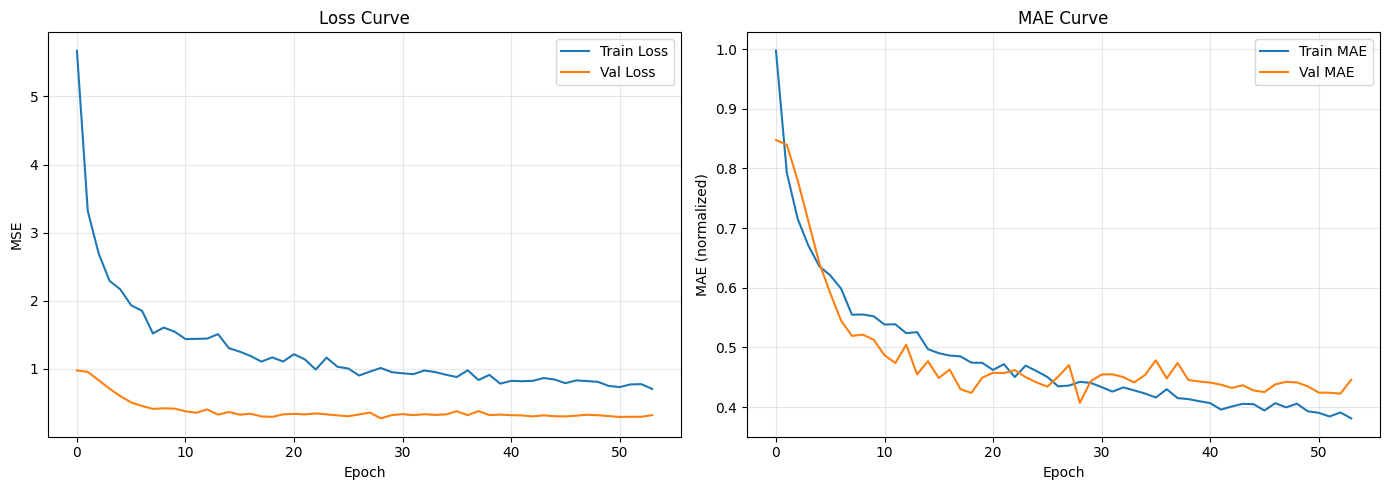


Best val MAE: 0.4070 (normalized) = 0.1864 C
Epochs trained: 54


In [ ]:
# ============================================================
# TRAINING
# ============================================================

# Target normalization
y_mean = y_tr.mean()
y_std = y_tr.std()
y_train_norm = (y_tr - y_mean) / y_std
y_val_norm = (y_va - y_mean) / y_std
print(f"Target: mean={y_mean:.4f}, std={y_std:.4f}")

# Sample weights
sample_weights = 1.0 + ELEVATED_WEIGHT_ALPHA * np.maximum(0, y_tr - ELEVATED_WEIGHT_THRESHOLD) ** 2
print(f"Weights: min={sample_weights.min():.2f}, max={sample_weights.max():.2f}, mean={sample_weights.mean():.2f}")

# Callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_mae', factor=LR_REDUCE_FACTOR,
                      patience=LR_REDUCE_PATIENCE, mode='min', verbose=1),
    EarlyStopping(monitor='val_mae', mode='min', patience=EARLY_STOP_PATIENCE,
                  restore_best_weights=True, verbose=1),
]

# Train
history = model.fit(
    [X_tr_d, X_tr_s], y_train_norm,
    validation_data=([X_va_d, X_va_s], y_val_norm),
    sample_weight=sample_weights,
    epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
)

# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE')
axes[0].set_title('Loss Curve'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE (normalized)')
axes[1].set_title('MAE Curve'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

best_val_mae_norm = min(history.history['val_mae'])
print(f"\nBest val MAE: {best_val_mae_norm:.4f} (normalized) = {best_val_mae_norm * y_std:.4f} C")
print(f"Epochs trained: {len(history.history['loss'])}")

## 7. Test Evaluation

In [ ]:
# ============================================================
# TEST SET EVALUATION
# ============================================================

y_pred_norm = model.predict([X_te_d, X_te_s], verbose=0).ravel()
y_pred = y_pred_norm * y_std + y_mean

# --- Regression ---
mae = mean_absolute_error(y_te, y_pred)
rmse = np.sqrt(mean_squared_error(y_te, y_pred))
r2 = r2_score(y_te, y_pred)
print(f"--- Test Regression ---")
print(f"  MAE:  {mae:.4f} C")
print(f"  RMSE: {rmse:.4f} C")
print(f"  R2:   {r2:.4f}")

# --- Threshold classification ---
print(f"\n--- Threshold Classification ---")
thresh_results = {}
for t in [38.0, 38.5, 39.0]:
    ap = y_te >= t; pp = y_pred >= t
    tp = np.sum(ap & pp); fp = np.sum(~ap & pp)
    fn = np.sum(ap & ~pp); tn = np.sum(~ap & ~pp)
    sens = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    f1 = 2*prec*sens/(prec+sens) if (prec+sens)>0 else 0
    print(f"\n  {t:.1f} C: Sens={sens:.3f}, Spec={spec:.3f}, Prec={prec:.3f}, F1={f1:.3f}")
    print(f"    TP={tp}, FP={fp}, FN={fn}, TN={tn}")
    thresh_results[t] = {'sens': sens, 'spec': spec, 'prec': prec, 'f1': f1}

# --- False alarm rate ---
for threshold in [38.5, 39.0]:
    safe = y_te < threshold; alarm = y_pred >= threshold
    fa = np.sum(safe & alarm); sh = np.sum(safe) / 60
    rate = fa / sh if sh > 0 else 0
    print(f"\n  FAR @ {threshold}: {fa} false alarms in {sh:.1f} safe-hours = {rate:.2f}/hr")

--- Test Regression ---
  MAE:  0.1834 C
  RMSE: 0.2342 C
  R2:   0.6528

--- Threshold Classification ---

  38.0 C: Sens=0.759, Spec=0.863, Prec=0.872, F1=0.811
    TP=129, FP=19, FN=41, TN=120

  38.5 C: Sens=0.465, Spec=0.989, Prec=0.870, F1=0.606
    TP=20, FP=3, FN=23, TN=263

  39.0 C: Sens=0.100, Spec=1.000, Prec=1.000, F1=0.182
    TP=1, FP=0, FN=9, TN=299

  FAR @ 38.5: 3 false alarms in 4.4 safe-hours = 0.68/hr

  FAR @ 39.0: 0 false alarms in 5.0 safe-hours = 0.00/hr


## 8. Plots

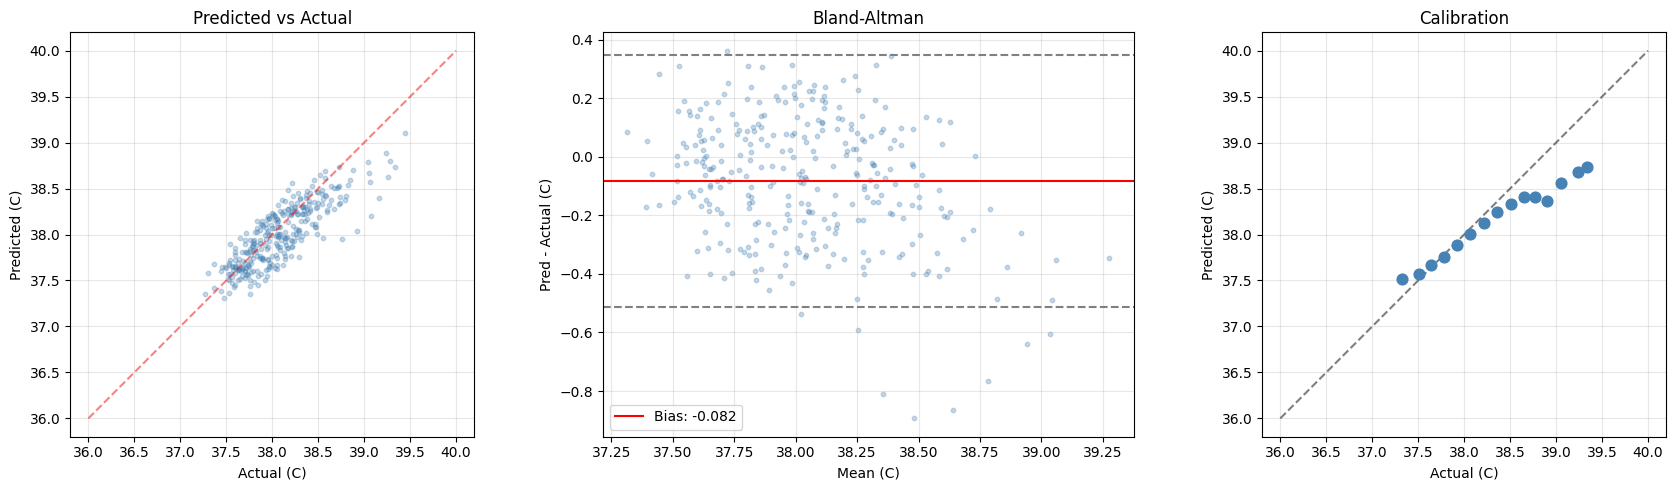

In [ ]:
# ============================================================
# PLOTS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter
ax = axes[0]
ax.scatter(y_te, y_pred, alpha=0.3, s=10, c='steelblue')
ax.plot([36, 40], [36, 40], 'r--', alpha=0.5)
ax.set_xlabel('Actual (C)'); ax.set_ylabel('Predicted (C)')
ax.set_title('Predicted vs Actual'); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

# Bland-Altman
ax = axes[1]
mean_vals = (y_te + y_pred) / 2
diff = y_pred - y_te
md = np.mean(diff); sd = np.std(diff)
ax.scatter(mean_vals, diff, alpha=0.3, s=10, c='steelblue')
ax.axhline(md, color='red', label=f'Bias: {md:.3f}')
ax.axhline(md + 1.96*sd, color='gray', linestyle='--')
ax.axhline(md - 1.96*sd, color='gray', linestyle='--')
ax.set_xlabel('Mean (C)'); ax.set_ylabel('Pred - Actual (C)')
ax.set_title('Bland-Altman'); ax.legend(); ax.grid(True, alpha=0.3)

# Calibration
ax = axes[2]
bins = np.linspace(y_te.min(), y_te.max(), 16)
ba, bp = [], []
for i in range(len(bins)-1):
    m = (y_te >= bins[i]) & (y_te < bins[i+1])
    if m.sum() > 0:
        ba.append(y_te[m].mean()); bp.append(y_pred[m].mean())
ax.plot([36, 40], [36, 40], 'k--', alpha=0.5)
ax.scatter(ba, bp, s=60, c='steelblue', zorder=5)
ax.set_xlabel('Actual (C)'); ax.set_ylabel('Predicted (C)')
ax.set_title('Calibration'); ax.set_aspect('equal'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

## 9. Per-Participant MAE

In [ ]:
# ============================================================
# PER-PARTICIPANT MAE
# ============================================================

print("--- Per-Participant MAE (Test Set) ---")
pp_results = {}
for pid, pdata in df_test.groupby('Participant'):
    y_true_list, y_pred_list = [], []
    for sid, session in pdata.groupby('Session_ID'):
        session = session.sort_values('Time_Sec')
        if len(session) < WINDOW_SIZE:
            continue
        dyn_vals = session[DYNAMIC_FEATURES].values
        stat_val = session[STATIC_FEATURES].iloc[0].values
        targets = session[TARGET].values
        for i in range(0, len(session) - WINDOW_SIZE + 1, WINDOW_SIZE):
            x_d = dyn_vals[i:i+WINDOW_SIZE][np.newaxis, ...]
            x_s = stat_val[np.newaxis, ...]
            p_norm = model.predict([x_d, x_s], verbose=0).ravel()[0]
            p = p_norm * y_std + y_mean
            y_true_list.append(targets[i + WINDOW_SIZE - 1])
            y_pred_list.append(p)
    if y_true_list:
        p_mae = mean_absolute_error(y_true_list, y_pred_list)
        pp_results[int(pid)] = {'mae': p_mae, 'n': len(y_true_list),
                                'mean': np.mean(y_true_list), 'max': np.max(y_true_list)}

for pid in sorted(pp_results.keys()):
    r = pp_results[pid]
    print(f"  P{pid}: MAE={r['mae']:.3f} C  (mean={r['mean']:.2f}, max={r['max']:.2f}, n={r['n']})")

--- Per-Participant MAE (Test Set) ---
  P8: MAE=0.200 C  (mean=38.04, max=38.49, n=12)
  P37: MAE=0.242 C  (mean=38.05, max=38.55, n=14)
  P44: MAE=0.145 C  (mean=37.92, max=39.26, n=20)
  P46: MAE=0.188 C  (mean=37.88, max=38.17, n=3)
  P49: MAE=0.225 C  (mean=38.10, max=38.85, n=10)
  P50: MAE=0.260 C  (mean=37.84, max=38.50, n=3)


## 10. Session Trajectories

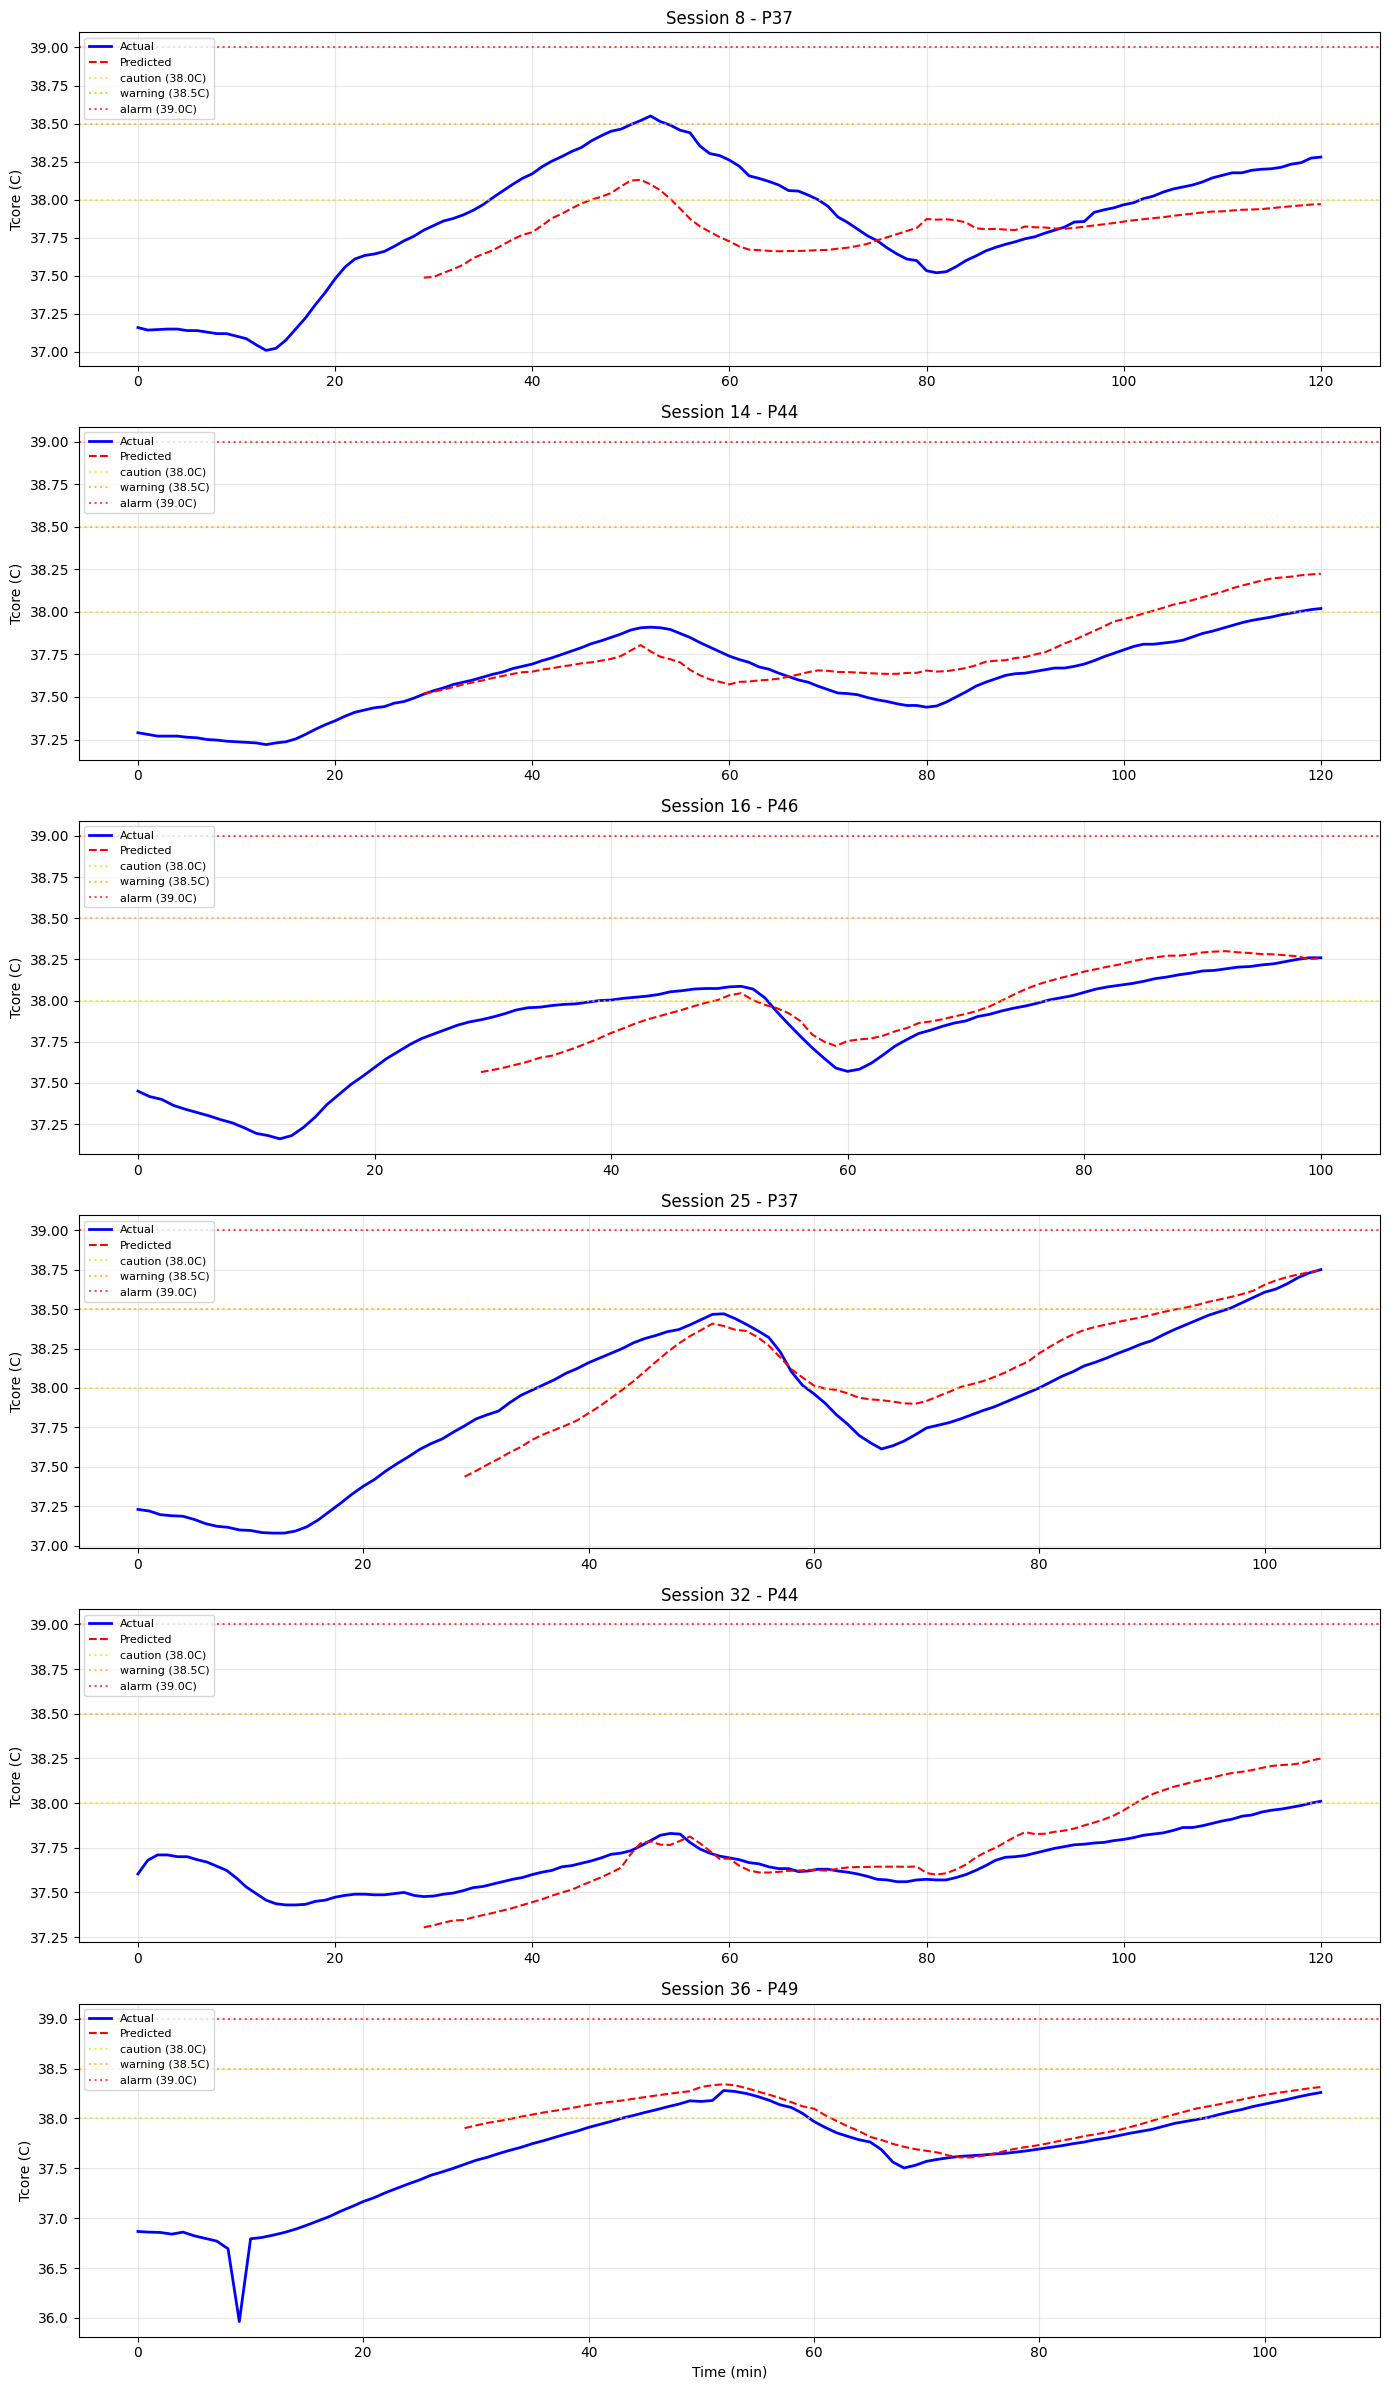

In [ ]:
# ============================================================
# SESSION TRAJECTORY PLOTS
# ============================================================

sessions = []
for sid, session in df_test.groupby('Session_ID'):
    session = session.sort_values('Time_Sec')
    if len(session) >= WINDOW_SIZE:
        sessions.append((sid, session))

n_plot = min(6, len(sessions))
if n_plot > 0:
    fig, axes = plt.subplots(n_plot, 1, figsize=(14, 4 * n_plot))
    if n_plot == 1: axes = [axes]
    for ax, (sid, session) in zip(axes, sessions[:n_plot]):
        pid = int(session['Participant'].iloc[0])
        time_min = (session['Time_Sec'].values - session['Time_Sec'].values[0]) / 60
        actual = session[TARGET].values
        dyn_vals = session[DYNAMIC_FEATURES].values
        stat_val = session[STATIC_FEATURES].iloc[0].values
        preds, ptimes = [], []
        for i in range(len(session) - WINDOW_SIZE + 1):
            x_d = dyn_vals[i:i+WINDOW_SIZE][np.newaxis, ...]
            x_s = stat_val[np.newaxis, ...]
            p = model.predict([x_d, x_s], verbose=0).ravel()[0] * y_std + y_mean
            preds.append(p); ptimes.append(time_min[i + WINDOW_SIZE - 1])
        ax.plot(time_min, actual, 'b-', lw=2, label='Actual')
        ax.plot(ptimes, preds, 'r--', lw=1.5, label='Predicted')
        for name, (lo, hi) in ALERT_THRESHOLDS.items():
            if name != 'normal' and lo < 40:
                color = {'caution': 'gold', 'warning': 'orange', 'alarm': 'red'}[name]
                ax.axhline(lo, color=color, ls=':', alpha=0.7, label=f'{name} ({lo}C)')
        ax.set_ylabel('Tcore (C)'); ax.set_title(f'Session {sid} - P{pid}')
        ax.legend(loc='upper left', fontsize=8); ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel('Time (min)')
    plt.tight_layout(); plt.show()

## 11. TFLite Export

In [ ]:
# ============================================================
# TFLITE EXPORT
# ============================================================

# Save Keras model
keras_path = os.path.join(MODEL_DIR, 'heatsense_lstm.keras')
model.save(keras_path)
print(f"Keras model saved: {keras_path}")

# Float32 TFLite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()
tflite_path = os.path.join(MODEL_DIR, 'heatsense_lstm.tflite')
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
size_f32 = len(tflite_model) / 1024
print(f"Float32 TFLite: {size_f32:.1f} KB")

# Dynamic-range quantized
converter_q = tf.lite.TFLiteConverter.from_keras_model(model)
converter_q.optimizations = [tf.lite.Optimize.DEFAULT]
try:
    tflite_q = converter_q.convert()
    tflite_q_path = os.path.join(MODEL_DIR, 'heatsense_lstm_int8.tflite')
    with open(tflite_q_path, 'wb') as f:
        f.write(tflite_q)
    size_q = len(tflite_q) / 1024
    print(f"Quantized TFLite: {size_q:.1f} KB")
except Exception as e:
    print(f"Quantization failed: {e}")
    size_q = None

# Validate
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()
inp = interpreter.get_input_details()
out = interpreter.get_output_details()

dyn_idx = next(d['index'] for d in inp if len(d['shape']) == 3)
stat_idx = next(d['index'] for d in inp if len(d['shape']) == 2)

n_val = min(50, len(X_te_d))
keras_p = model.predict([X_te_d[:n_val], X_te_s[:n_val]], verbose=0).ravel()
tfl_p = []
for i in range(n_val):
    interpreter.set_tensor(dyn_idx, X_te_d[i:i+1])
    interpreter.set_tensor(stat_idx, X_te_s[i:i+1])
    interpreter.invoke()
    tfl_p.append(interpreter.get_tensor(out[0]['index']).ravel()[0])
tfl_mae = np.mean(np.abs(np.array(keras_p) - np.array(tfl_p))) * y_std
print(f"\nKeras vs TFLite MAE diff: {tfl_mae:.6f} C (tolerance: 0.05 C)")
print(f"PASS: {tfl_mae < 0.05}")

# Save target norm
with open(os.path.join(MODEL_DIR, 'scalers_lstm.pkl'), 'rb') as f:
    sd = pickle.load(f)
sd['target_mean'] = float(y_mean)
sd['target_std'] = float(y_std)
with open(os.path.join(MODEL_DIR, 'scalers_lstm.pkl'), 'wb') as f:
    pickle.dump(sd, f)

Keras model saved: /content/drive/MyDrive/HeatSense/output/models/heatsense_lstm.keras
Saved artifact at '/tmp/tmp9khd38xz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 30, 10), dtype=tf.float32, name='dynamic_input'), TensorSpec(shape=(None, 6), dtype=tf.float32, name='static_input')]
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  134635661140688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134635661139152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134635661133008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134635661137808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134635661141072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134635661141456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134635661136272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134635661135888: TensorSpec(shape=(), dtype=tf.resource, name=None)

ConverterError: <unknown>:0: error: loc(callsite(callsite(fused["TensorListReserve:", "HeatSense_LSTM_1/lstm_1/TensorArrayV2_1@__inference_function_57055"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_57136"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): 'tf.TensorListReserve' op requires element_shape to be static during TF Lite transformation pass
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"]): called from
<unknown>:0: error: loc(callsite(callsite(fused["TensorListReserve:", "HeatSense_LSTM_1/lstm_1/TensorArrayV2_1@__inference_function_57055"] at fused["StatefulPartitionedCall:", "StatefulPartitionedCall@__inference_signature_wrapper_57136"]) at fused["StatefulPartitionedCall:", "StatefulPartitionedCall_1"])): failed to legalize operation 'tf.TensorListReserve' that was explicitly marked illegal
<unknown>:0: note: loc(fused["StatefulPartitionedCall:", "StatefulPartitionedCal

## 12. Comparison vs XGBoost Baseline

In [ ]:
# ============================================================
# COMPARISON
# ============================================================

xgb_mae = 0.2303
xgb_rmse = 0.2908
xgb_r2 = 0.4648
xgb_sens38 = 0.635
xgb_sens385 = 0.419
xgb_f1_38 = 0.725
xgb_f1_385 = 0.581

print("=" * 70)
print("  MODEL COMPARISON: XGBoost vs LSTM")
print("=" * 70)
print(f"{'Metric':<25} {'XGBoost':>12} {'LSTM':>12} {'Winner':>10}")
print("-" * 70)

def winner(a, b, higher_better=False):
    if higher_better:
        return 'LSTM' if b > a else 'XGBoost' if a > b else 'Tie'
    return 'LSTM' if b < a else 'XGBoost' if a < b else 'Tie'

print(f"{'MAE (C)':<25} {xgb_mae:>12.4f} {mae:>12.4f} {winner(xgb_mae, mae):>10}")
print(f"{'RMSE (C)':<25} {xgb_rmse:>12.4f} {rmse:>12.4f} {winner(xgb_rmse, rmse):>10}")
print(f"{'R2':<25} {xgb_r2:>12.4f} {r2:>12.4f} {winner(xgb_r2, r2, True):>10}")
print(f"{'Sens @ 38.0':<25} {xgb_sens38:>12.3f} {thresh_results[38.0]['sens']:>12.3f} {winner(xgb_sens38, thresh_results[38.0]['sens'], True):>10}")
print(f"{'Sens @ 38.5':<25} {xgb_sens385:>12.3f} {thresh_results[38.5]['sens']:>12.3f} {winner(xgb_sens385, thresh_results[38.5]['sens'], True):>10}")
print(f"{'F1 @ 38.0':<25} {xgb_f1_38:>12.3f} {thresh_results[38.0]['f1']:>12.3f} {winner(xgb_f1_38, thresh_results[38.0]['f1'], True):>10}")
print(f"{'F1 @ 38.5':<25} {xgb_f1_385:>12.3f} {thresh_results[38.5]['f1']:>12.3f} {winner(xgb_f1_385, thresh_results[38.5]['f1'], True):>10}")
print(f"{'Bias (C)':<25} {'~':>12} {md:>12.4f} {'':>10}")
print("-" * 70)
print(f"{'TFLite size (KB)':<25} {'N/A (tree)':>12} {size_f32:>12.1f}")
if size_q:
    print(f"{'Quantized (KB)':<25} {'N/A':>12} {size_q:>12.1f}")
print("=" * 70)

print(f"\nLSTM trained for {len(history.history['loss'])} epochs")
print(f"Best val MAE: {best_val_mae_norm * y_std:.4f} C")

  MODEL COMPARISON: XGBoost vs LSTM
Metric                         XGBoost         LSTM     Winner
----------------------------------------------------------------------
MAE (C)                         0.2303       0.1834       LSTM
RMSE (C)                        0.2908       0.2342       LSTM
R2                              0.4648       0.6528       LSTM
Sens @ 38.0                      0.635        0.759       LSTM
Sens @ 38.5                      0.419        0.465       LSTM
F1 @ 38.0                        0.725        0.811       LSTM
F1 @ 38.5                        0.581        0.606       LSTM
Bias (C)                             ~      -0.0821           
----------------------------------------------------------------------


NameError: name 'size_f32' is not defined